## **Odhalování** FAKE NEWS


### Načítání knihoven


In [1]:
import pandas as pd                       # Práce s datovými rámci (tabulkami)
import re                                 # Práce s regulárními výrazy (čištění textu)
import nltk                               # Přirozené zpracování jazyka (tokenizace, stop slova, lemmatizace)
from nltk.corpus import stopwords         # Stop slova pro angličtinu
from nltk.stem import WordNetLemmatizer   # Lemmatizace slov
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer # BOW a TF-IDF
from sklearn.preprocessing import LabelEncoder # Kódování kategorií na čísla
import tensorflow as tf                   # Práce s neuronovými sítěmi
import matplotlib.pyplot as plt           # Vizualizace (grafy)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
from wordcloud import WordCloud
from collections import Counter

### Předzpracování textu

In [2]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
# Nastaví množinu stop slov a lemmatizátor.
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [4]:
def preprocess_text(text):
     # text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    # stop words
    tokens = [w for w in tokens if w not in stop_words]
    # lemmatizér
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

### Stažení a načtení dat

In [5]:
import kagglehub
path = kagglehub.dataset_download("aadyasingh55/fake-news-classification")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fake-news-classification


In [6]:
test_df = pd.read_csv('/content/test (1).csv', delimiter = ';')
train_df = pd.read_csv('/content/train (2).csv', delimiter = ';')
eval_df = pd.read_csv('/content/evaluation.csv', delimiter = ';')

In [7]:
counts = train_df['label'].value_counts()
print("Počet 0 (FAKE):", counts.get(0, 0))
print("Počet 1 (REAL):", counts.get(1, 0))

Počet 0 (FAKE): 2142
Počet 1 (REAL): 2599


In [10]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print(df)

       Unnamed: 0                                              title  \
0               0  Palestinians switch off Christmas lights in Be...   
1               1  China says Trump call with Taiwan president wo...   
2               2   FAIL! The Trump Organization’s Credit Score W...   
3               3  Zimbabwe military chief's China trip was norma...   
4               4  THE MOST UNCOURAGEOUS PRESIDENT EVER Receives ...   
...           ...                                                ...   
14615        5372  Michael Bloomberg may launch independent U.S. ...   
14616        5373  Philippine lawmakers reject fifth Duterte cabi...   
14617        5374  YOU’LL NEVER BELIEVE WHICH REPUBLICAN JUST CAL...   
14618        5375  Tillerson arrives in Bonn amid questions over ...   
14619        5376   Dan Rather Responds To Trump’s Sex Tape Alleg...   

                                                    text  label  word_count  
0      RAMALLAH, West Bank (Reuters) - Palestinians s... 

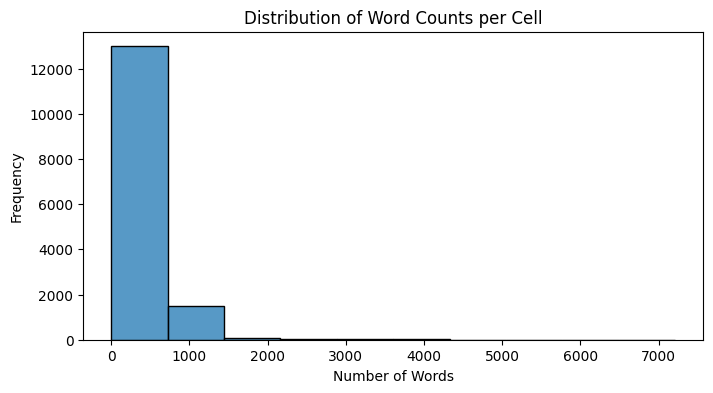

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(df['word_count'], bins=10)
plt.title('Distribution of Word Counts per Cell')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()


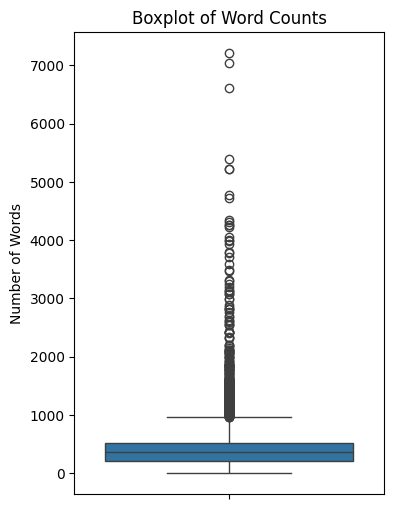

In [12]:
plt.figure(figsize=(4, 6))
sns.boxplot(y=df['word_count'])
plt.title('Boxplot of Word Counts')
plt.ylabel('Number of Words')
plt.show()

### Sloučení a vyčištění textu

In [ ]:
# Sloučení sloupců Title a Text
train_df['slouceno'] = train_df['title'] + train_df['text']
test_df['slouceno'] = test_df['title'] + test_df['text']
eval_df['slouceno'] = eval_df['title'] + eval_df['text']

In [ ]:
# "Vyčistíme" nový sloupec podle funkce preprocess_text
train_df['upraveno'] = train_df['slouceno'].apply(preprocess_text)
test_df['upraveno'] = test_df['slouceno'].apply(preprocess_text)
eval_df['upraveno'] = eval_df['slouceno'].apply(preprocess_text)

### Label Encoding

In [ ]:
# Převede textové štítky (např. FAKE/REAL) na čísla (0/1).
le = LabelEncoder()
train_df['label_enc'] = le.fit_transform(train_df['label'])
test_df['label_enc'] = le.transform(test_df['label'])
eval_df['label_enc'] = le.transform(eval_df['label'])

### Příprava vstupů a výstupů

In [ ]:
# Vytvoříme proměnné pro vstupy a výstupy pro různé části dat
X_train = train_df['upraveno']
X_test = test_df['upraveno']
X_eval = eval_df['upraveno']
y_train = train_df['label_enc']
y_test = test_df['label_enc']
y_eval = eval_df ['label_enc']

# Modelování

## Model Bag Of Words

Príprava

In [ ]:
# Převede texty na vektory podle důležitosti slov v dokumentu a celé kolekci
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)
X_eval_bow = bow_vectorizer.transform(X_eval)

In [ ]:
# LabelEncoder již zná všechny unikátní třídy, le.classes_ obsahuje všechny tyto třídy ve formě seznamu, len určuje jejich po4et
num_classes = len(le.classes_)
#  Funkcí to.categorical převedeme číselné štítky (0, 1) na one-hot vektory, , což je formát, ve kterém neuronové sítě často očekávají výstupy při klasifikaci tříd.
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)
y_eval_cat = tf.keras.utils.to_categorical(y_eval, num_classes)

Model

In [ ]:
# Převede texty na vektory podle důležitosti slov v dokumentu a celé kolekci
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)
X_eval_bow = bow_vectorizer.transform(X_eval)

In [ ]:
"""
1.Vytvoříme sekvenční model, kde vrstvy jdou za sebou ve správném pořadí.
2. Dense vrstva plně propojená vrstva s 64 neurony, funkce ReLU, běžná u skrytých vrstev, input_dim=X_train_bow.shape[1]: počet vstupních funkcí (features),
  - `X_train_bow.shape[1]` je počet sloupců v matici `X_train_bow`, což je počet slov (max_features=5000), které jsme použili při vektorizaci textu.Tato hodnota určuje velikost vstupního vektoru
3. Další skrytá vrstva s 32 neurony, opět s aktivací ReLU. Přijímá výstup z předchozí vrstvy.
4. Výstupní vrstva, num_classes: počet tříd, activation sigmoid pro binární klasifikaci.
"""
model_bow = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_dim=X_train_bow.shape[1]),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='sigmoid')
    ])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',  # monitor validation loss
    patience=3,          # wait 3 epochs before stopping
    restore_best_weights=True)

In [ ]:
model_bow.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history_bow = model_bow.fit(X_train_bow.toarray(), y_train_cat, epochs=10, batch_size=32,
                            validation_data=(X_test_bow.toarray(), y_test_cat))

Epoch 1/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9412 - loss: 0.1839 - val_accuracy: 0.9756 - val_loss: 0.0774
Epoch 2/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9875 - loss: 0.0319 - val_accuracy: 0.9786 - val_loss: 0.0751
Epoch 3/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9945 - loss: 0.0162 - val_accuracy: 0.9800 - val_loss: 0.0867
Epoch 4/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9976 - loss: 0.0080 - val_accuracy: 0.9782 - val_loss: 0.0998
Epoch 5/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9983 - loss: 0.0059 - val_accuracy: 0.9766 - val_loss: 0.1284
Epoch 6/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9982 - loss: 0.0074 - val_accuracy: 0.9768 - val_loss: 0.1326
Epoch 7/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9983 - loss: 0.0095 - val_accuracy: 0.9767 - val_loss: 0.1208
Epoch 8/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy:

## Model TF-IDF

Príprava

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
X_eval_tfidf = tfidf_vectorizer.transform(X_eval)

Model

In [ ]:
model_tfidf = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu', input_dim=X_train_tfidf.shape[1]),
    tf.keras.layers.Dense(2, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='sigmoid')
])

In [ ]:
model_tfidf.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history_tfidf = model_tfidf.fit(X_train_tfidf.toarray(), y_train_cat, epochs=10, batch_size=32,
                                validation_data=(X_test_tfidf.toarray(), y_test_cat))

Epoch 1/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9070 - loss: 0.5096 - val_accuracy: 0.9692 - val_loss: 0.1250
Epoch 2/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9731 - loss: 0.1051 - val_accuracy: 0.9773 - val_loss: 0.0743
Epoch 3/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9819 - loss: 0.0608 - val_accuracy: 0.9787 - val_loss: 0.0648
Epoch 4/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9896 - loss: 0.0348 - val_accuracy: 0.9791 - val_loss: 0.0633
Epoch 5/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9943 - loss: 0.0260 - val_accuracy: 0.9781 - val_loss: 0.0663
Epoch 6/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9971 - loss: 0.0179 - val_accuracy: 0.9779 - val_loss: 0.0716
Epoch 7/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9985 - loss: 0.0117 - val_accuracy: 0.9773 - val_loss: 0.0761
Epoch 8/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9992 - loss: 0.0078 - val_accuracy: 0.

## Model Embedding

Príprava

In [ ]:
max_num_words = 10000
max_sequence_length = 200

In [ ]:
# Nastavíme maximální počet slov, která Tokenizer bude rozlišovat (vytvoří slovník s 10 000 nejčastějšími slovy)
max_words = 10000
# Nastavíme maximální délku sekvence (věty) - kratší doplní nulami, delší ořízne
max_len = 200
# Vytvoříme Tokenizer, který bude pracovat jen s max_num_words nejčastějšími slovy
tokenizer = Tokenizer(num_words=max_words)
# Naučíme Tokenizer slovník z trénovacích textů (přiřadí indexy slovům)
tokenizer.fit_on_texts(X_train)

In [ ]:
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['label'])
test_labels = label_encoder.transform(test_df['label'])
eval_labels = label_encoder.transform(eval_df['label'])

In [ ]:
# Převede trénovací, testovací a evaluační texty na sekvence čísel (indexů slov)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_eval_seq = tokenizer.texts_to_sequences(X_eval)

In [ ]:
# Zarovná všechny sekvence na stejnou délku (kratší doplní nulami, delší ořízne)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_sequence_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_sequence_length)
X_eval_pad = pad_sequences(X_eval_seq, maxlen=max_sequence_length)


In [ ]:
embedding_dim = 100
num_words = min(max_num_words, len(tokenizer.word_index) + 1)

model_nn = Sequential()
model_nn.add(Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=max_sequence_length))
model_nn.add(SpatialDropout1D(0.2))
model_nn.add(LSTM(64))
model_nn.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Kompilace modelu - nastaví ztrátovou funkci, optimalizátor a metriku přesnosti
model_nn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history_nn = model_nn.fit(X_train_pad, train_labels, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 81s 256ms/step - accuracy: 0.8830 - loss: 0.3052 - val_accuracy: 0.9555 - val_loss: 0.1246
Epoch 2/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 78s 243ms/step - accuracy: 0.9750 - loss: 0.0811 - val_accuracy: 0.9665 - val_loss: 0.0968
Epoch 3/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 75s 246ms/step - accuracy: 0.9802 - loss: 0.0595 - val_accuracy: 0.9583 - val_loss: 0.1298
Epoch 4/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 80s 241ms/step - accuracy: 0.9401 - loss: 0.1910 - val_accuracy: 0.9407 - val_loss: 0.1584
Epoch 5/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 94s 280ms/step - accuracy: 0.9643 - loss: 0.0940 - val_accuracy: 0.9532 - val_loss: 0.1336
Epoch 6/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 74s 241ms/step - accuracy: 0.9807 - loss: 0.0560 - val_accuracy: 0.9433 - val_loss: 0.1641
Epoch 7/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 87s 257ms/step - accuracy: 0.9807 - loss: 0.0522 - val_accuracy: 0.9540 - val_loss: 0.1448
Epoch 8/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 77s 242ms/step - accuracy: 0.9911 - loss: 0

# Srovnání modelů

## Přesnost

Validační přesnost

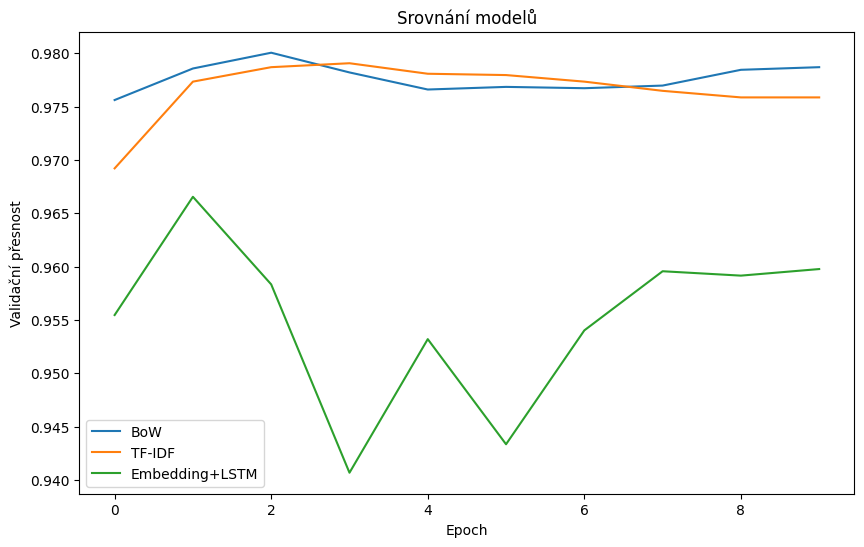

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history_bow.history['val_accuracy'], label='BoW')
plt.plot(history_tfidf.history['val_accuracy'], label='TF-IDF')
plt.plot(history_nn.history['val_accuracy'], label='Embedding+LSTM')
plt.xlabel('Epoch')
plt.ylabel('Validační přesnost')
plt.title('Srovnání modelů')
plt.legend()

Společná funkce pro vykreslení průběhu tréninku

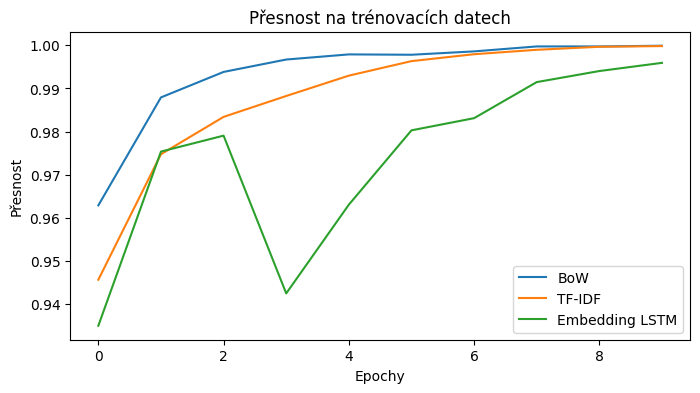

In [ ]:
plt.figure(figsize=(8, 4))
plt.title('Přesnost na trénovacích datech')
plt.plot(history_bow.history['accuracy'], label='BoW')
plt.plot(history_tfidf.history['accuracy'], label='TF-IDF')
plt.plot(history_nn.history['accuracy'], label='Embedding LSTM')
plt.xlabel('Epochy')
plt.ylabel('Přesnost')
plt.legend()
plt.show()

/tmp/ipython-input-39-408128638.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(best_val_acc.keys()), y=list(best_val_acc.values()), palette='viridis')


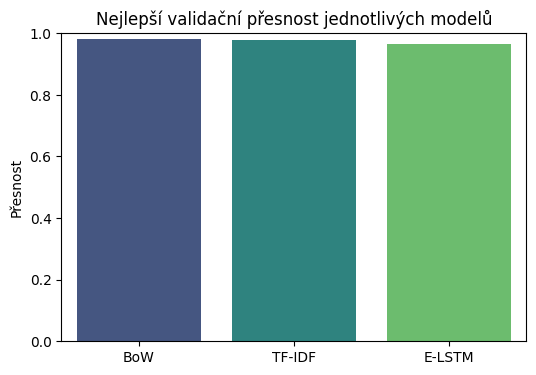

In [ ]:
best_val_acc = {
    'BoW'   : max(history_bow.history['val_accuracy']),
    'TF-IDF': max(history_tfidf.history['val_accuracy']),
    'E-LSTM'  : max(history_nn.history['val_accuracy'])
}
plt.figure(figsize=(6,4))
sns.barplot(x=list(best_val_acc.keys()), y=list(best_val_acc.values()), palette='viridis')
plt.ylim(0,1)
plt.title('Nejlepší validační přesnost jednotlivých modelů')
plt.ylabel('Přesnost')
plt.show()

## Confusion matice

In [ ]:
true_eval_labels = eval_labels

In [ ]:
pred_eval_bow = np.argmax(model_bow.predict(X_eval_bow.toarray()), axis=1)
cm_bow = confusion_matrix(true_eval_labels, pred_eval_bow)

254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
pred_eval_tfidf = np.argmax(model_tfidf.predict(X_eval_tfidf.toarray()), axis=1)
cm_tfidf = confusion_matrix(true_eval_labels, pred_eval_tfidf)

254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
pred_eval_nn = (model_nn.predict(X_eval_pad) > 0.5).astype(int).ravel()
cm_nn = confusion_matrix(true_eval_labels, pred_eval_nn)

254/254 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step


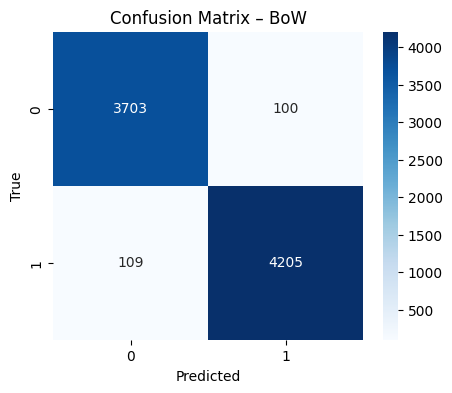

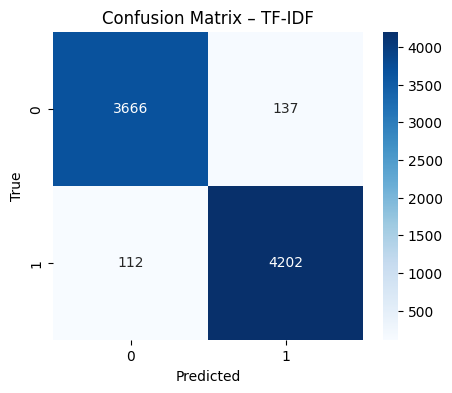

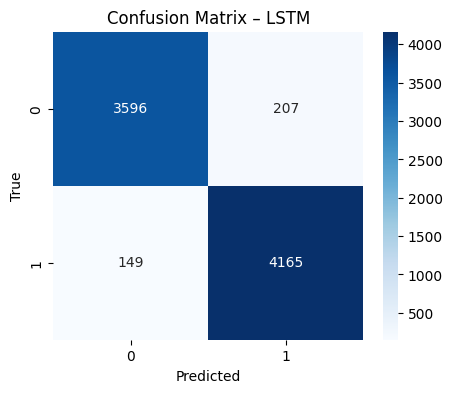

In [ ]:
def draw_cm(cm, title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

draw_cm(cm_bow,   'Confusion Matrix – BoW')
draw_cm(cm_tfidf, 'Confusion Matrix – TF-IDF')
draw_cm(cm_nn,    'Confusion Matrix – LSTM')

# Ověření nejlepšího modelu - BoW na validačních datech

In [ ]:
model_bow_val = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_dim=X_eval_bow.shape[1]),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='sigmoid')
    ])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_bow_val.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history_bow_val = model_bow_val.fit(X_train_bow.toarray(), y_train_cat, epochs=10, batch_size=32,
                            validation_data=(X_eval_bow.toarray(), y_eval_cat))

Epoch 1/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9358 - loss: 0.1938 - val_accuracy: 0.9749 - val_loss: 0.0702
Epoch 2/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9888 - loss: 0.0308 - val_accuracy: 0.9735 - val_loss: 0.0771
Epoch 3/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9956 - loss: 0.0140 - val_accuracy: 0.9738 - val_loss: 0.0980
Epoch 4/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9974 - loss: 0.0090 - val_accuracy: 0.9718 - val_loss: 0.1137
Epoch 5/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9977 - loss: 0.0068 - val_accuracy: 0.9710 - val_loss: 0.1480
Epoch 6/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9984 - loss: 0.0070 - val_accuracy: 0.9709 - val_loss: 0.1513
Epoch 7/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9990 - loss: 0.0064 - val_accuracy: 0.9661 - val_loss: 0.1755
Epoch 8/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9992 - loss: 0.0037 - val_accur

In [ ]:
true_labels = le.inverse_transform(eval_df['label'].map(lambda x: le.transform([x])[0]))

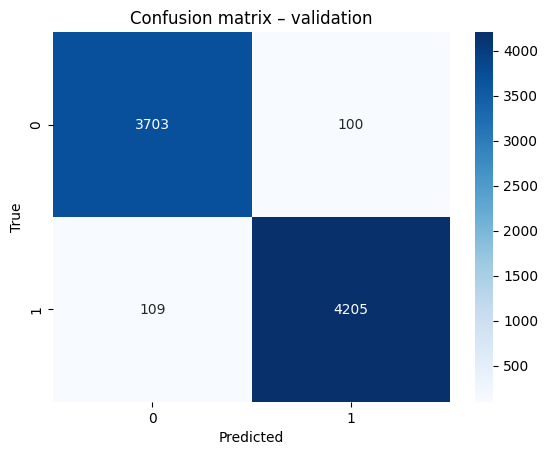

In [ ]:
cm = confusion_matrix(eval_labels, pred_eval_bow)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion matrix – validation')
plt.show()

In [ ]:
print(classification_report(eval_labels, pred_eval_bow, digits=4))

              precision    recall  f1-score   support

           0     0.9714    0.9737    0.9726      3803
           1     0.9768    0.9747    0.9758      4314

    accuracy                         0.9743      8117
   macro avg     0.9741    0.9742    0.9742      8117
weighted avg     0.9743    0.9743    0.9743      8117



# Wordclouds

In [9]:
df = pd.concat([train_df, test_df, eval_df], ignore_index=True)

In [ ]:
def clean_and_tokenize(text):
    words = re.findall(r'\b[a-z]+\b', str(text).lower())
    words = [w for w in words if w not in stop_words]
    return words

In [ ]:
texts_label1 = df[df['label'] == 1]['text']
texts_label0 = df[df['label'] == 0]['text']

In [ ]:
words_real = [word for text in df[df['label'] == 1]['text'] for word in clean_and_tokenize(text)]
words_fake = [word for text in df[df['label'] == 0]['text'] for word in clean_and_tokenize(text)]

In [ ]:
freq_real = Counter(words_real)
freq_fake = Counter(words_fake)

## REAL

In [ ]:
wordcloud_real = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate_from_frequencies(freq_real)
wordcloud_fake = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate_from_frequencies(freq_fake)

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

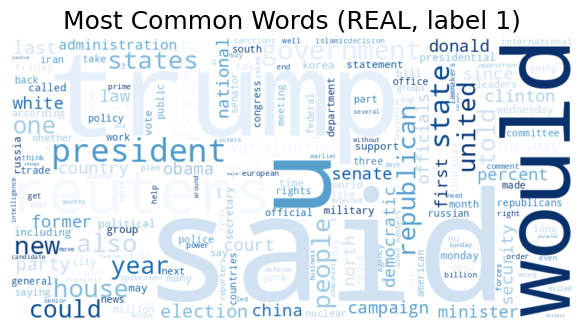

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.title('Most Common Words (REAL, label 1)', fontsize=18)
plt.axis('off')

## FAKE

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

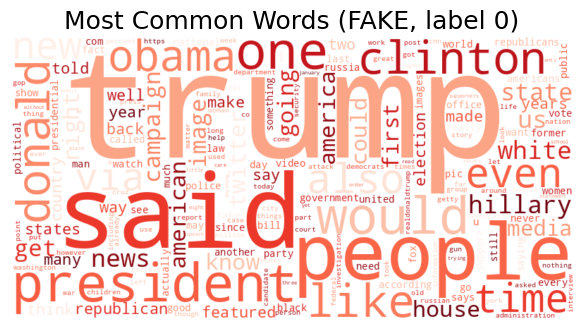

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.title('Most Common Words (FAKE, label 0)', fontsize=18)
plt.axis('off')

In [ ]:
top5_label1 = Counter(words_real).most_common(5)
top5_label0 = Counter(words_fake).most_common(5)

In [ ]:
print("Top 5 words for label 1 (REAL):")
for word, count in top5_label1:
    print(f"{word}: {count}")

print("\nTop 5 words for label 0 (FAKE):")
for word, count in top5_label0:
    print(f"{word}: {count}")

Top 5 words for label 1 (REAL):
said: 98756
trump: 55448
u: 44017
would: 32081
reuters: 28699

Top 5 words for label 0 (FAKE):
trump: 69939
said: 26066
people: 22395
president: 21395
one: 20209


## ONLY FAKE

In [ ]:
unique_fake_words = {word: count for word, count in freq_fake.items() if word not in freq_real}
top5_unique_fake = Counter(unique_fake_words).most_common(5)

In [ ]:
print("Top 5 words in FAKE not in REAL:")
for word, count in top5_unique_fake:
    print(f"{word}: {count}")

Top 5 words in FAKE not in REAL:
https: 3515
quot: 1000
js: 887
flickr: 601
fjs: 441


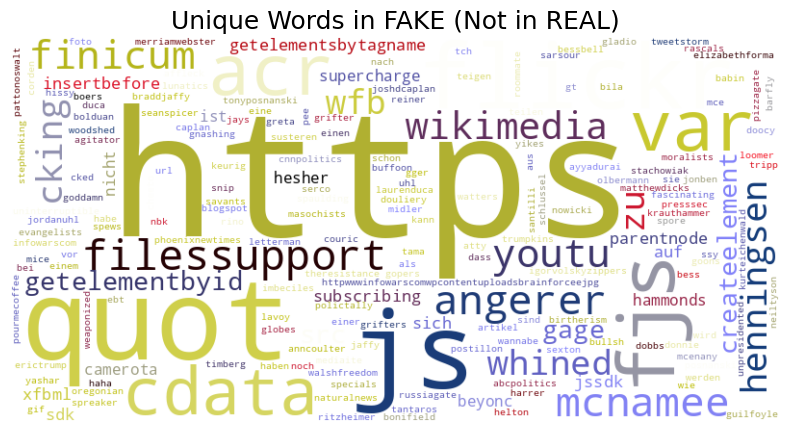

In [ ]:
wordcloud_unique_fake = WordCloud(width=800, height=400, background_color='white', colormap='gist_stern').generate_from_frequencies(unique_fake_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_unique_fake, interpolation='bilinear')
plt.title('Unique Words in FAKE (Not in REAL)', fontsize=18)
plt.axis('off')
plt.show()

## ONLY REAL

In [ ]:
unique_real_words = {word: count for word, count in freq_real.items() if word not in freq_fake}
top5_unique_real = Counter(unique_real_words).most_common(5)

In [ ]:
print("Top 5 words in FAKE not in REAL:")
for word, count in top5_unique_real:
    print(f"{word}: {count}")

Top 5 words in FAKE not in REAL:
rakhine: 888
puigdemont: 641
fdp: 516
mnangagwa: 395
rajoy: 386


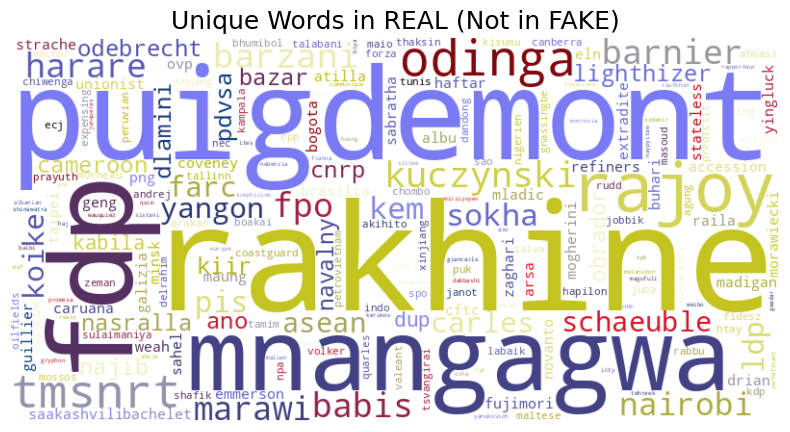

In [ ]:
wordcloud_unique_real = WordCloud(width=800, height=400, background_color='white', colormap='gist_stern').generate_from_frequencies(unique_real_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_unique_real, interpolation='bilinear')
plt.title('Unique Words in REAL (Not in FAKE)', fontsize=18)
plt.axis('off')
plt.show()